# Ejercicio 1 — Calidad del vino (Wine Quality)

Trabajas en una bodega de vinos. Te dan datos químicos de 1,599 vinos tintos y su calidad (puntaje de 3 a 8 dado por catadores expertos). Tu misión: construir un modelo que prediga la calidad a partir de las propiedades químicas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'
cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

df = pd.read_csv(url, names=cols, header=0)
print(f'Shape: {df.shape}')


Shape: (1598, 12)


In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

Primeras filas del DataFrame:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
5,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
6,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
7,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
8,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5


Ultimas filas del DataFrame:
      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
1593            6.2             0.600         0.08             2.0      0.090   
1594            5.9             0.550         0.10             2.2      0.062   
1595            6.3             0.510         0.13             2.3      0.076   
1596            5.9             0.645         0.12             2.0      0.075   
1597            6.0             0.310         0.47             3.6      0.067   

      free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
1593                 32.0                  44.0  0.99490  3.45       0.58   
1594                 39.0                  51.0  0.99512  3.52       0.76   
1595                 29.0                  40.0  0.99574  3.42       0.75   
1596                 32.0                  44.0  0.99547  3.57       0.71   
1597                 18.0                  42.0  0.99549  3.39       0.66   

      alcohol  qualit

In [4]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    1598.000000       1598.000000  1598.000000     1598.000000   
mean        8.320213          0.527713     0.271145        2.539205   
std         1.741489          0.179064     0.194744        1.410279   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  1598.000000          1598.000000           1598.000000  1598.000000   
mean      0.087474            15.877972             46.475594     0.996746   
std       0.047079            10.462720             32.904142     0.001888   
min    

In [5]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [6]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 239


In [7]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


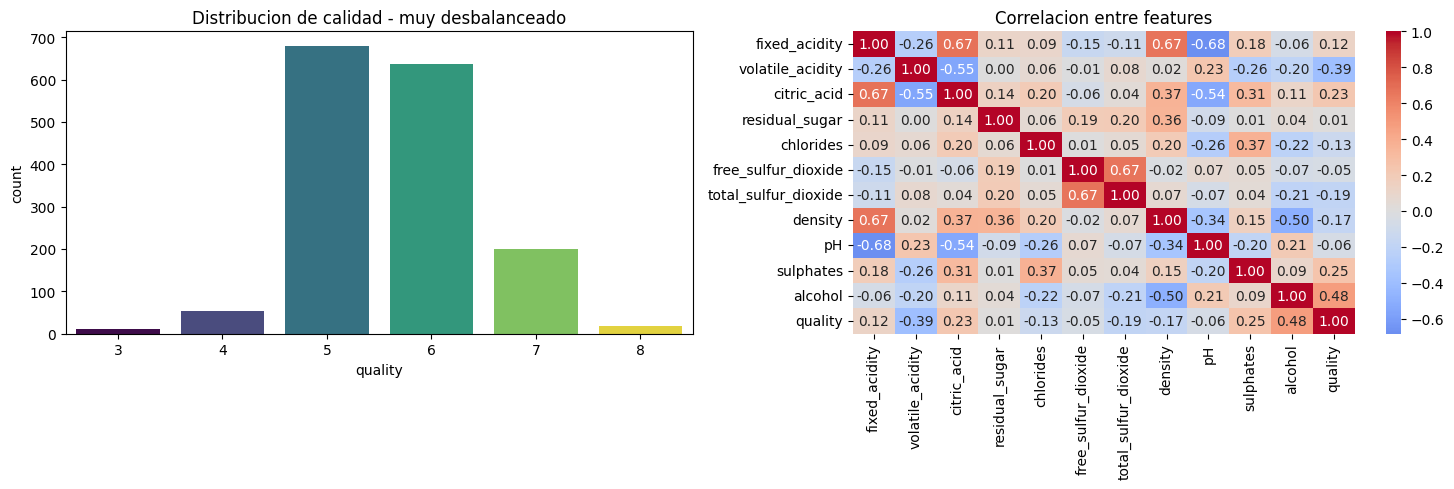

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribucion de calidad - muy desbalanceado')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlacion entre features')
plt.tight_layout(); plt.show()

In [9]:
X = df.drop(columns=['quality'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc =  scaler.transform(X_test)

In [11]:
modelos = {'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=0.05), 'Bagging': BaggingRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=100, n_jobs=-1, random_state=42), 'RF': RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)}

resultados = []
for nombre, m in modelos.items():
    Xtr, Xte = (X_train_esc, X_test_esc) if nombre in ['Ridge', 'Lasso'] else (X_train, X_test)
    m.fit(Xtr, y_train)
    pred = m.predict(Xte)
    resultados.append({'Modelo': nombre, 'R²': r2_score(y_test, pred), 'MAE': mean_absolute_error(y_test, pred), 'RMSE': np.sqrt(mean_squared_error(y_test, pred))})

tabla = pd.DataFrame(resultados).set_index('Modelo').sort_values('R²', ascending=False).round(4)
print('\nComparacion de modelos:')
print(tabla)


Comparacion de modelos:
             R²     MAE    RMSE
Modelo                         
RF       0.4764  0.4289  0.5703
Bagging  0.4584  0.4466  0.5800
Ridge    0.3295  0.5112  0.6453
Lasso    0.3082  0.5266  0.6555


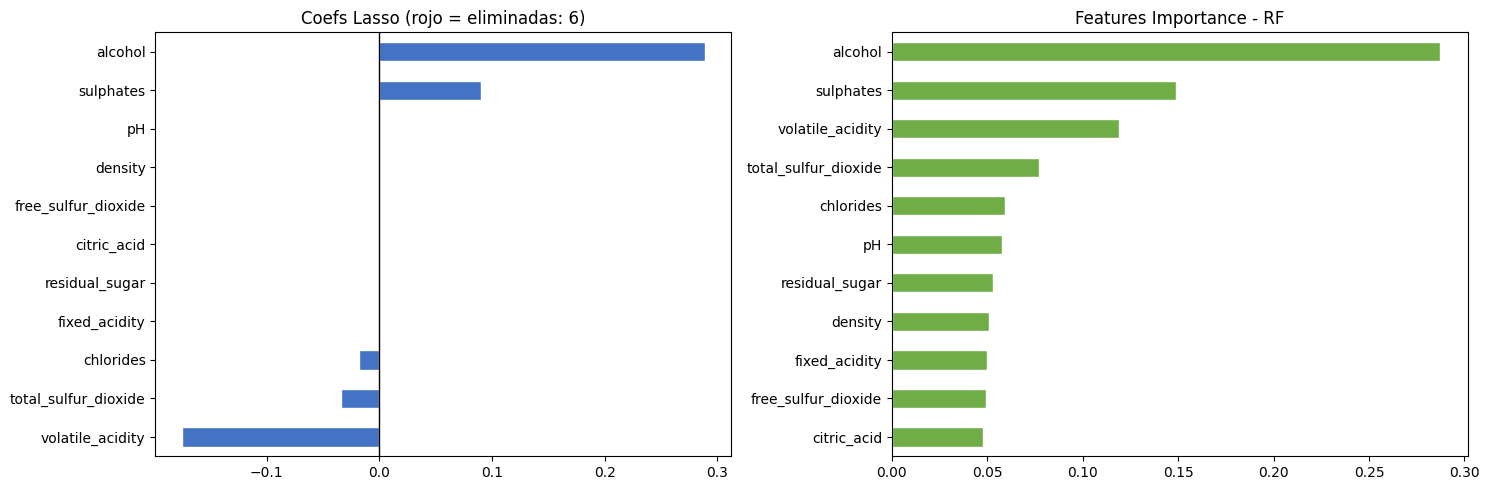

In [15]:
lasso = modelos['Lasso']
rf = modelos['RF']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

coefs = pd.Series(lasso.coef_, index=X.columns).sort_values()
colores = ['#C0504D' if c == 0 else '#4472C4' for c in coefs.values]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Coefs Lasso (rojo = eliminadas: {(coefs==0).sum()})')

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', color='#70AD47', edgecolor='white', ax=axes[1])
axes[1].set_title('Features Importance - RF')

plt.tight_layout(); plt.show()

In [16]:
vino_nuevo = pd.DataFrame([{'fixed_acidity': 7.4, 'volatile_acidity': 0.7, 'citric_acid': 0.0, 'residual_sugar': 1.9, 'chlorides': 0.076, 'free_sulfur_dioxide': 11.0, 'total_sulfur_dioxide': 34.0, 'density': 0.9978, 'pH': 3.51, 'sulphates': 0.56, 'alcohol': 9.4}])

print('\n Prediccion de calidad para el vino nuevo:')
for nombre, m in modelos.items():
    Xnew = scaler.transform(vino_nuevo) if nombre in ['Ridge', 'Lasso'] else vino_nuevo
    print(f' {nombre:8s}  calidad = {m.predict(Xnew)[0]:.2f}')


 Prediccion de calidad para el vino nuevo:
 Ridge     calidad = 5.05
 Lasso     calidad = 5.16
 Bagging   calidad = 5.16
 RF        calidad = 5.06
